In [12]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

In [18]:
seed_df = pd.read_csv(r"seed_engagement_metric_with_subscribers.csv")
bridge_df = pd.read_csv(r"bridge_engagement_metric_with_subscribers.csv")

In [19]:
# Filter dates
start_date = '2022-02-25'
end_date = '2024-04-01'

seed_df = seed_df[(seed_df['date'] >= start_date) &
                                    (seed_df['date'] <= end_date)]

bridge_df = bridge_df[(bridge_df['date'] >= start_date) & 
                                        (bridge_df['date'] <= end_date)]

In [25]:
seed_df.columns

Index(['channel_id', 'channel_name', 'message', 'date', 'msg_link', 'has_url',
       'views', 'number_replies', 'number_forwards', 'contains_media',
       'duration_of_post', 'subscribers_count'],
      dtype='object')

/var/folders/y1/cnlqxwt920n6g3pt9v0hqy840000gn/T/ipykernel_17727/1445260663.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  bridge_monthly_avg = bridge_df['number_forwards'].resample('M').mean()
/var/folders/y1/cnlqxwt920n6g3pt9v0hqy840000gn/T/ipykernel_17727/1445260663.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  seed_monthly_avg = seed_df['number_forwards'].resample('M').mean()


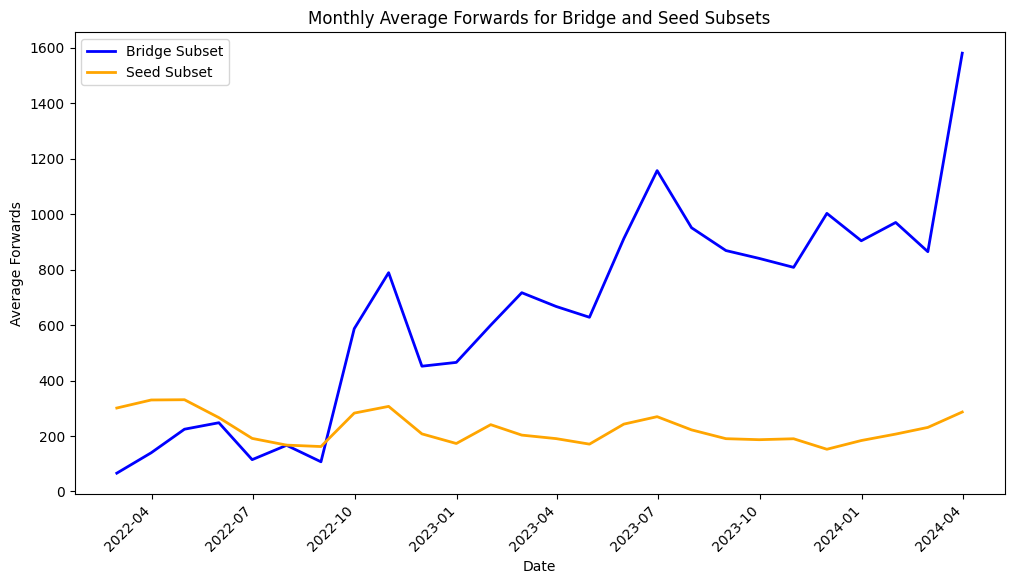

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

bridge_df['date'] = pd.to_datetime(bridge_df['date'])
seed_df['date'] = pd.to_datetime(seed_df['date'])

# Set the date column as index
bridge_df.set_index('date',drop=False, inplace=True)
seed_df.set_index('date', drop=False, inplace=True)

# Resample the data to monthly frequency and calculate the mean of views for each month
bridge_monthly_avg = bridge_df['number_forwards'].resample('M').mean()
seed_monthly_avg = seed_df['number_forwards'].resample('M').mean()

# Plot the line graph for monthly averages
plt.figure(figsize=(12, 6))
plt.plot(bridge_monthly_avg, label='Bridge Subset', color='blue', linewidth=2)
plt.plot(seed_monthly_avg, label='Seed Subset', color='orange', linewidth=2)

# Add labels, title, and legend
plt.xlabel('Date')
plt.ylabel('Average Forwards')
plt.title('Monthly Average Forwards for Bridge and Seed Subsets')
plt.legend()

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Show the plot
plt.show()



Statistical Comparison:
                    Bridge Subset  Seed Subset
Mean                       712.56       227.40
Median                      89.00        70.00
Standard Deviation        1859.42       671.51
Min                          0.00         0.00
Max                     129411.00     86480.00
25th Percentile             19.00        17.00
75th Percentile            646.00       214.00


/var/folders/y1/cnlqxwt920n6g3pt9v0hqy840000gn/T/ipykernel_17727/2094271345.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([bridge_df['number_forwards'], seed_df['number_forwards']],


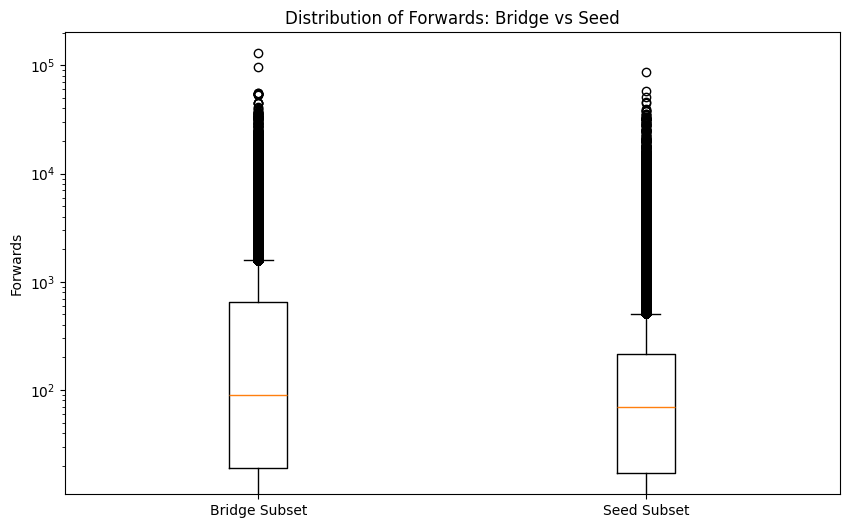

In [26]:
# Calculate statistics for both DataFrames
def get_statistics(df):
    stats = {
        'Mean': df['number_forwards'].mean(),
        'Median': df['number_forwards'].median(),
        'Standard Deviation': df['number_forwards'].std(),
        'Min': df['number_forwards'].min(),
        'Max': df['number_forwards'].max(),
        '25th Percentile': df['number_forwards'].quantile(0.25),
        '75th Percentile': df['number_forwards'].quantile(0.75)
    }
    return pd.Series(stats)

# Calculate statistics for both datasets
bridge_stats = get_statistics(bridge_df)
seed_stats = get_statistics(seed_df)

# Combine statistics into a single DataFrame
comparison_df = pd.DataFrame({
    'Bridge Subset': bridge_stats,
    'Seed Subset': seed_stats
})

# Format numbers to be more readable
comparison_df = comparison_df.round(2)

# Display the comparison
print("\nStatistical Comparison:")
print(comparison_df)

# Create a box plot to visualize the distribution
plt.figure(figsize=(10, 6))
plt.boxplot([bridge_df['number_forwards'], seed_df['number_forwards']], 
            labels=['Bridge Subset', 'Seed Subset'])
plt.title('Distribution of Forwards: Bridge vs Seed')
plt.yscale('log')
plt.ylabel('Forwards')
plt.show()

In [27]:
import numpy as np

# Normalize number_forwards for bridge subset
bridge_df['normalized_number_forwards(Only_Subscriber)'] = (
    bridge_df['number_forwards'] / 
    (bridge_df['subscribers_count'])
)  * 100

# Normalize number_forwards for seed subset
seed_df['normalized_number_forwards(Only_Subscriber)'] = (
    seed_df['number_forwards'] / 
    (seed_df['subscribers_count'])
)  * 100


Statistical Comparison:
                    Bridge Subset  Seed Subset
Mean                         0.10        16.47
Median                       0.03         0.03
Standard Deviation           0.49        72.55
Min                          0.00         0.00
Max                         54.60     15242.17
25th Percentile              0.02         0.01
75th Percentile              0.08         0.19


/var/folders/y1/cnlqxwt920n6g3pt9v0hqy840000gn/T/ipykernel_17727/3464585796.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([bridge_df['normalized_number_forwards(Only_Subscriber)'], seed_df['normalized_number_forwards(Only_Subscriber)']],


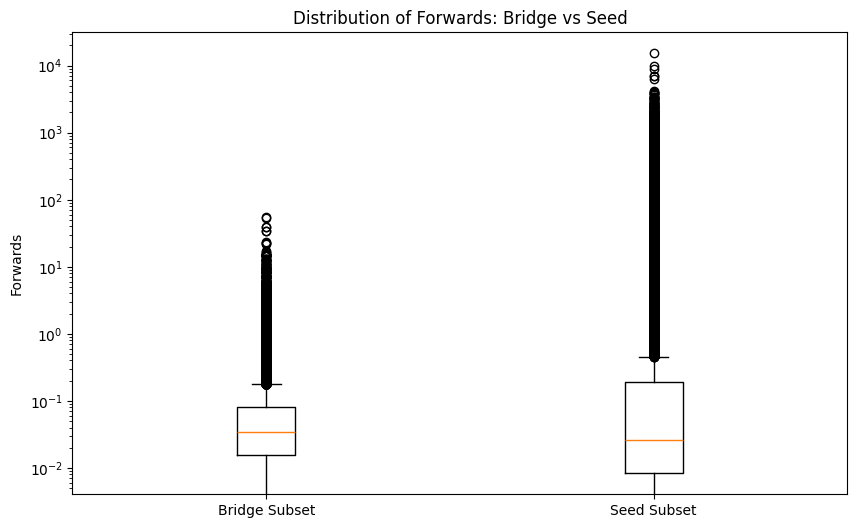

In [28]:
# Calculate statistics for both DataFrames
def get_statistics(df):
    stats = {
        'Mean': df['normalized_number_forwards(Only_Subscriber)'].mean(),
        'Median': df['normalized_number_forwards(Only_Subscriber)'].median(),
        'Standard Deviation': df['normalized_number_forwards(Only_Subscriber)'].std(),
        'Min': df['normalized_number_forwards(Only_Subscriber)'].min(),
        'Max': df['normalized_number_forwards(Only_Subscriber)'].max(),
        '25th Percentile': df['normalized_number_forwards(Only_Subscriber)'].quantile(0.25),
        '75th Percentile': df['normalized_number_forwards(Only_Subscriber)'].quantile(0.75)
    }
    return pd.Series(stats)

# Calculate statistics for both datasets
bridge_stats = get_statistics(bridge_df)
seed_stats = get_statistics(seed_df)

# Combine statistics into a single DataFrame
comparison_df = pd.DataFrame({
    'Bridge Subset': bridge_stats,
    'Seed Subset': seed_stats
})

# Format numbers to be more readable
comparison_df = comparison_df.round(2)

# Display the comparison
print("\nStatistical Comparison:")
print(comparison_df)

# Create a box plot to visualize the distribution
plt.figure(figsize=(10, 6))
plt.boxplot([bridge_df['normalized_number_forwards(Only_Subscriber)'], seed_df['normalized_number_forwards(Only_Subscriber)']], 
            labels=['Bridge Subset', 'Seed Subset'])
plt.title('Distribution of Forwards: Bridge vs Seed')
plt.yscale('log')
plt.ylabel('Forwards')
plt.show()

In [29]:
seed_df.columns

Index(['channel_id', 'channel_name', 'message', 'date', 'msg_link', 'has_url',
       'views', 'number_replies', 'number_forwards', 'contains_media',
       'duration_of_post', 'subscribers_count',
       'normalized_number_forwards(Only_Subscriber)'],
      dtype='object')

Bridge DataFrame - Weekly Spikes in Forwards:
Baseline Mean: 656.68, Baseline Std Dev: 428.65, Threshold: 1299.65
Number of spike weeks: 3
Bridge DataFrame - Weekly Spikes in Normalized Forwards:
Baseline Mean: 0.11, Baseline Std Dev: 0.12, Threshold: 0.29
Number of spike weeks: 3
Seed DataFrame - Weekly Spikes in Forwards:
Baseline Mean: 223.21, Baseline Std Dev: 62.20, Threshold: 316.51
Number of spike weeks: 13
Seed DataFrame - Weekly Spikes in Normalized Forwards:
Baseline Mean: 16.55, Baseline Std Dev: 6.78, Threshold: 26.72
Number of spike weeks: 7


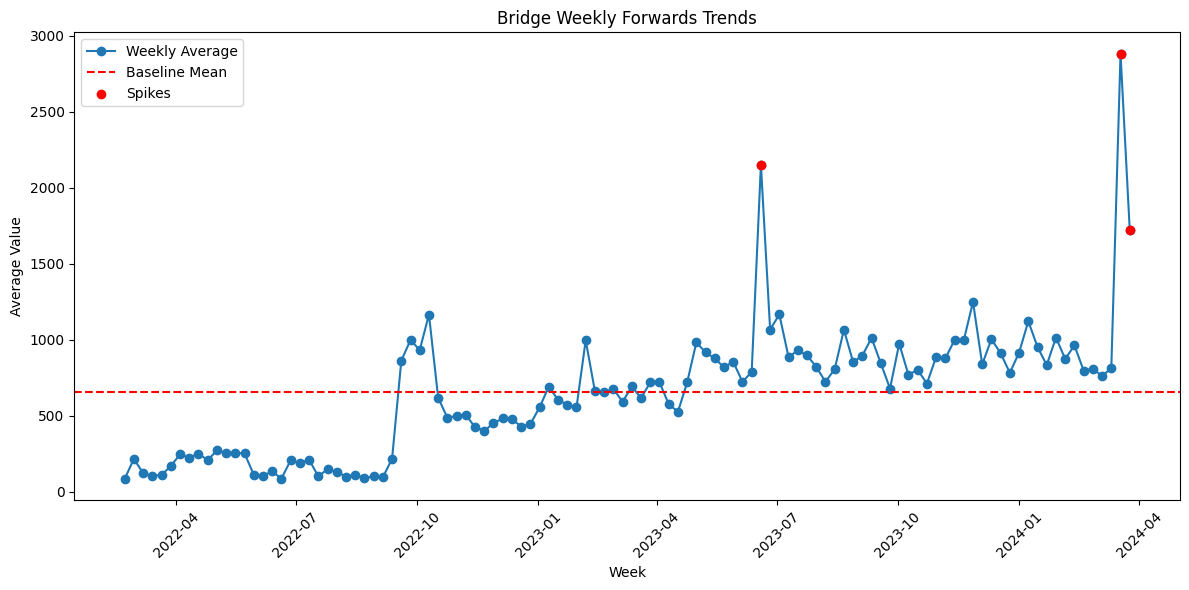

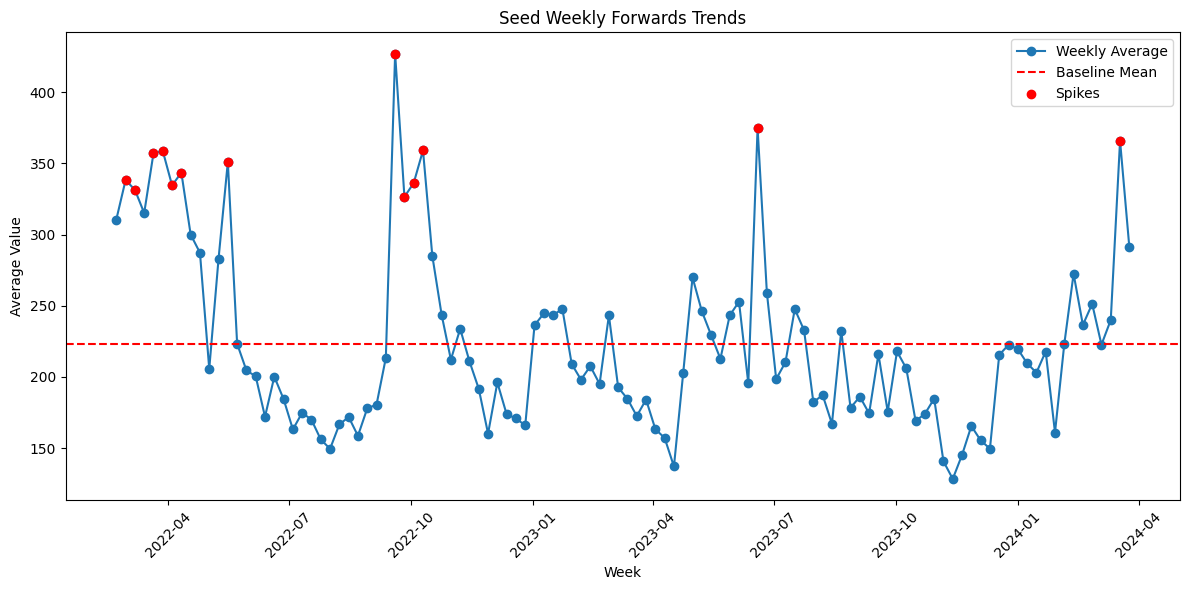

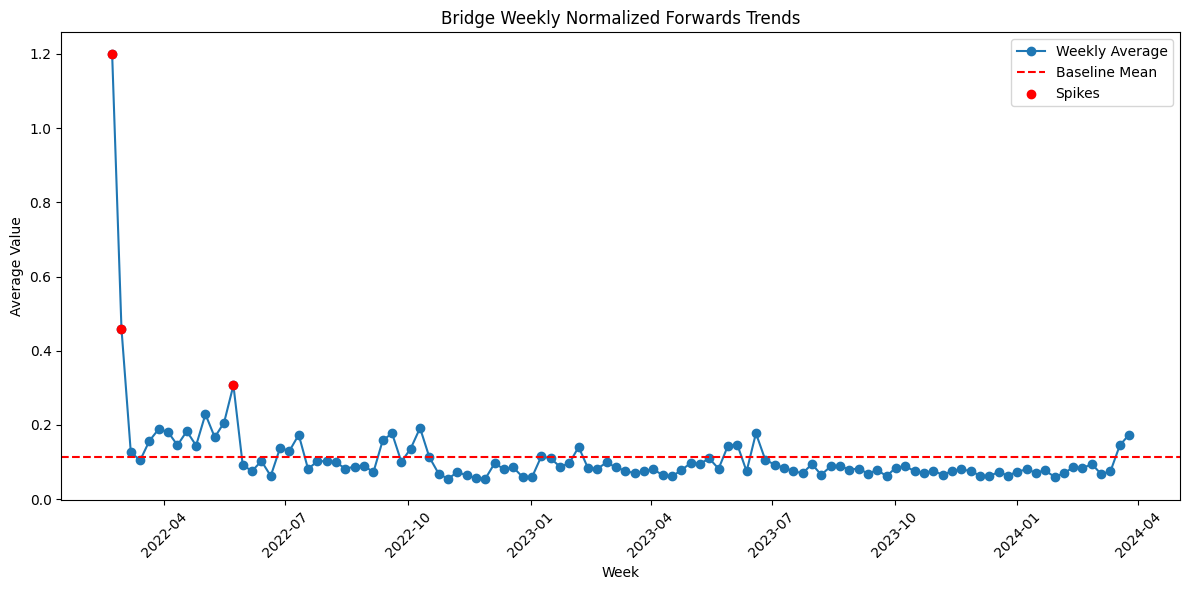

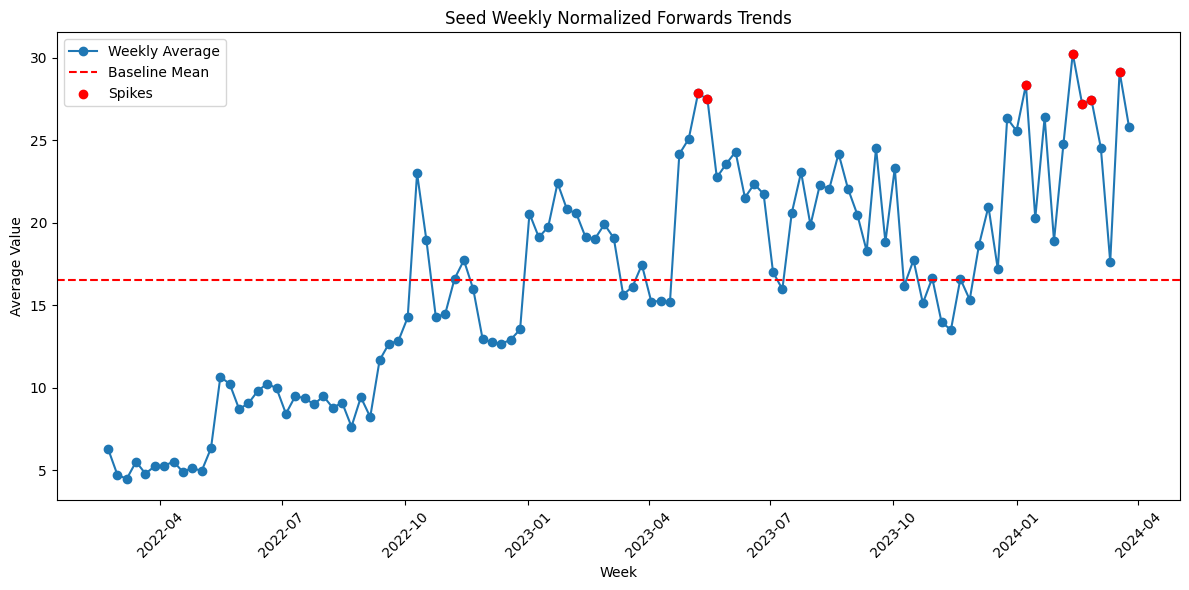

In [30]:
def find_weekly_spikes(df, value_column, date_column='date', threshold_factor=1.5):
    # Ensure the date column is in datetime format
    df[date_column] = pd.to_datetime(df[date_column])
    
    # Create a new column for the week (start of the week)
    df['week'] = df[date_column].dt.to_period('W').apply(lambda r: r.start_time)
    
    # Aggregate weekly data
    weekly_aggregated = df.groupby('week')[value_column].mean().reset_index()
    weekly_aggregated.rename(columns={value_column: 'weekly_avg'}, inplace=True)
    
    # Calculate baseline and threshold
    baseline_mean = weekly_aggregated['weekly_avg'].mean()
    baseline_std = weekly_aggregated['weekly_avg'].std()
    threshold = baseline_mean + threshold_factor * baseline_std
    
    # Identify weeks with spikes
    weekly_aggregated['is_spike'] = weekly_aggregated['weekly_avg'] > threshold
    
    # Filter for spike weeks
    spikes = weekly_aggregated[weekly_aggregated['is_spike']]
    
    print(f"Baseline Mean: {baseline_mean:.2f}, Baseline Std Dev: {baseline_std:.2f}, Threshold: {threshold:.2f}")
    print(f"Number of spike weeks: {len(spikes)}")
    return spikes, weekly_aggregated

# Apply this to bridge_df and seed_df for 'forwards' and 'normalized_forwards(Only_Subscriber)'
print("Bridge DataFrame - Weekly Spikes in Forwards:")
bridge_weekly_spikes_forwards, bridge_weekly_data_forwards = find_weekly_spikes(bridge_df, 'number_forwards')

print("Bridge DataFrame - Weekly Spikes in Normalized Forwards:")
bridge_weekly_spikes_norm, bridge_weekly_data_norm = find_weekly_spikes(bridge_df, 'normalized_number_forwards(Only_Subscriber)')

print("Seed DataFrame - Weekly Spikes in Forwards:")
seed_weekly_spikes_forwards, seed_weekly_data_forwards = find_weekly_spikes(seed_df, 'number_forwards')

print("Seed DataFrame - Weekly Spikes in Normalized Forwards:")
seed_weekly_spikes_norm, seed_weekly_data_norm = find_weekly_spikes(seed_df, 'normalized_number_forwards(Only_Subscriber)')

# Visualization (optional)
import matplotlib.pyplot as plt
def plot_weekly_trends(weekly_data, value_column='weekly_avg', spike_column='is_spike', title='Weekly Trends'):
    plt.figure(figsize=(12, 6))
    plt.plot(weekly_data['week'], weekly_data[value_column], label='Weekly Average', marker='o')
    plt.axhline(y=weekly_data[value_column].mean(), color='r', linestyle='--', label='Baseline Mean')
    spike_weeks = weekly_data[weekly_data[spike_column]]
    plt.scatter(spike_weeks['week'], spike_weeks[value_column], color='red', label='Spikes', zorder=5)
    plt.xlabel('Week')
    plt.ylabel('Average Value')
    plt.title(title)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_weekly_trends(bridge_weekly_data_forwards, title='Bridge Weekly Forwards Trends')

plot_weekly_trends(seed_weekly_data_forwards, title='Seed Weekly Forwards Trends')

plot_weekly_trends(bridge_weekly_data_norm, title='Bridge Weekly Normalized Forwards Trends')

plot_weekly_trends(seed_weekly_data_norm, title='Seed Weekly Normalized Forwards Trends')

In [31]:
# Get the exact dates of the weekly peaks
def get_peak_weeks(spike_data, weekly_data, date_column='week'):
    peak_weeks = weekly_data[weekly_data['week'].isin(spike_data['week'])]
    peak_weeks_dates = peak_weeks[date_column]
    return peak_weeks_dates

# For Bridge DataFrame (forwards)
bridge_peak_weeks_forwards = get_peak_weeks(bridge_weekly_spikes_forwards, bridge_weekly_data_forwards)
print("Bridge Weekly Spikes (Exact Dates) - forwards:")
print(bridge_peak_weeks_forwards)

# For Bridge DataFrame (Normalized forwards)
bridge_peak_weeks_norm = get_peak_weeks(bridge_weekly_spikes_norm, bridge_weekly_data_norm)
print("Bridge Weekly Spikes (Exact Dates) - Normalized forwards:")
print(bridge_peak_weeks_norm)

# For Seed DataFrame (forwards)
seed_peak_weeks_forwards = get_peak_weeks(seed_weekly_spikes_forwards, seed_weekly_data_forwards)
print("Seed Weekly Spikes (Exact Dates) - forwards:")
print(seed_peak_weeks_forwards)

# For Seed DataFrame (Normalized forwards)
seed_peak_weeks_norm = get_peak_weeks(seed_weekly_spikes_norm, seed_weekly_data_norm)
print("Seed Weekly Spikes (Exact Dates) - Normalized forwards:")
print(seed_peak_weeks_norm)


Bridge Weekly Spikes (Exact Dates) - forwards:
69    2023-06-19
108   2024-03-18
109   2024-03-25
Name: week, dtype: datetime64[ns]
Bridge Weekly Spikes (Exact Dates) - Normalized forwards:
0    2022-02-21
1    2022-02-28
13   2022-05-23
Name: week, dtype: datetime64[ns]
Seed Weekly Spikes (Exact Dates) - forwards:
1     2022-02-28
2     2022-03-07
4     2022-03-21
5     2022-03-28
6     2022-04-04
7     2022-04-11
12    2022-05-16
30    2022-09-19
31    2022-09-26
32    2022-10-03
33    2022-10-10
69    2023-06-19
108   2024-03-18
Name: week, dtype: datetime64[ns]
Seed Weekly Spikes (Exact Dates) - Normalized forwards:
63    2023-05-08
64    2023-05-15
98    2024-01-08
103   2024-02-12
104   2024-02-19
105   2024-02-26
108   2024-03-18
Name: week, dtype: datetime64[ns]


Bridge DataFrame - Weekly Spikes in forwards (Median):
Baseline Median: 91.00, MAD: 44.50, Threshold: 157.75
Number of spike weeks: 26
Bridge DataFrame - Weekly Spikes in Normalized Views (Median):
Baseline Median: 0.04, MAD: 0.00, Threshold: 0.04
Number of spike weeks: 23
Seed DataFrame - Weekly Spikes in Views (Median):
Baseline Median: 69.00, MAD: 12.00, Threshold: 87.00
Number of spike weeks: 23
Seed DataFrame - Weekly Spikes in Normalized Views (Median):
Baseline Median: 0.03, MAD: 0.01, Threshold: 0.03
Number of spike weeks: 18


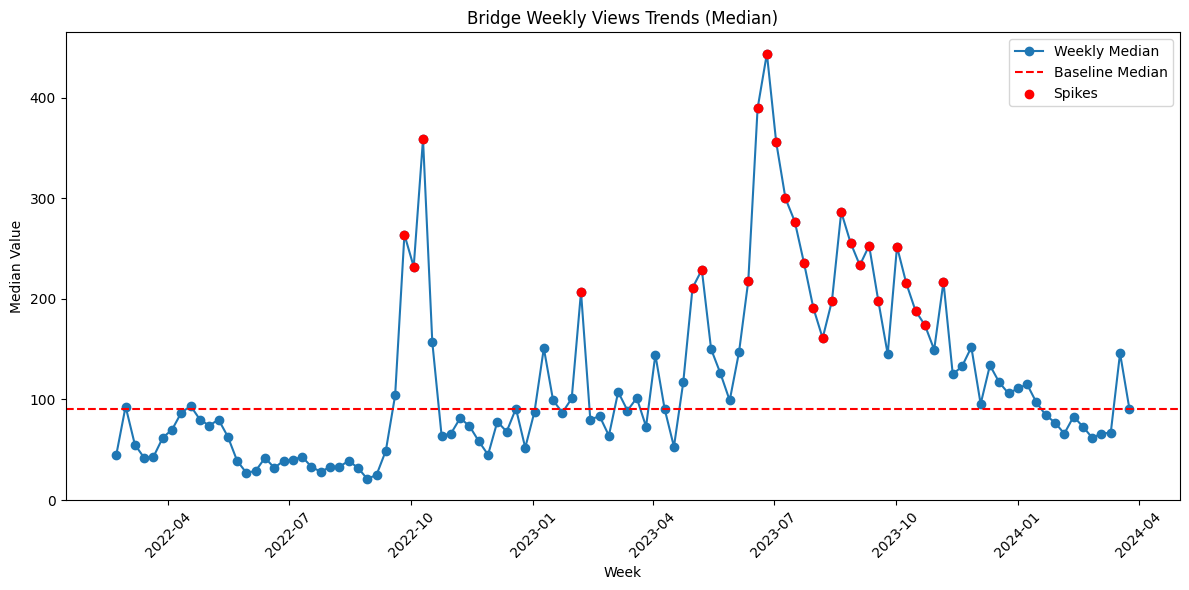

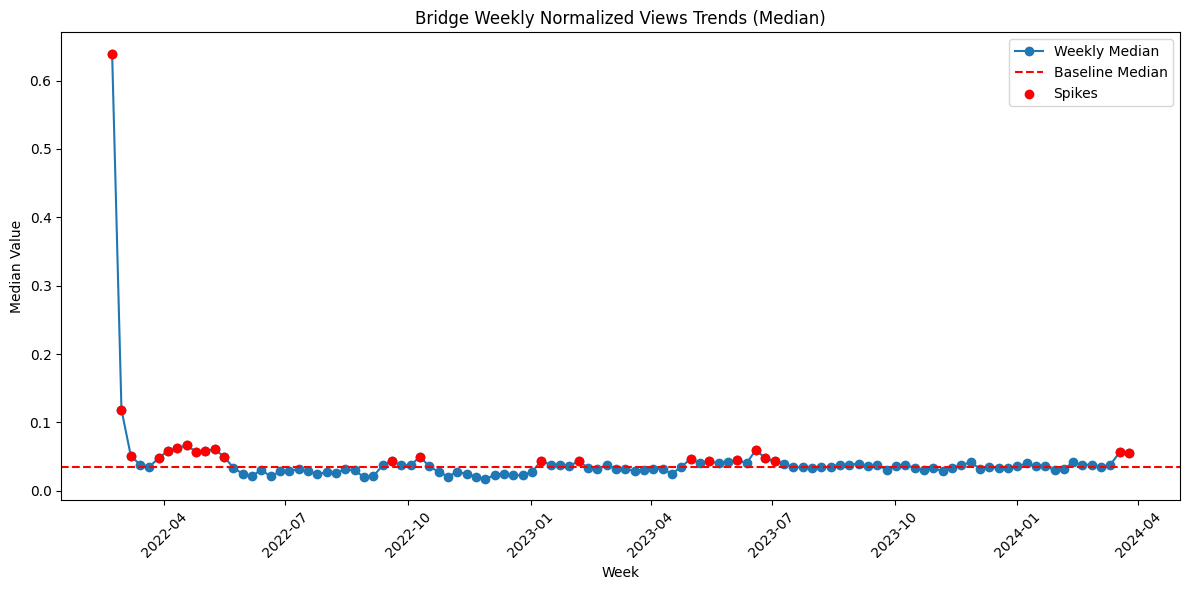

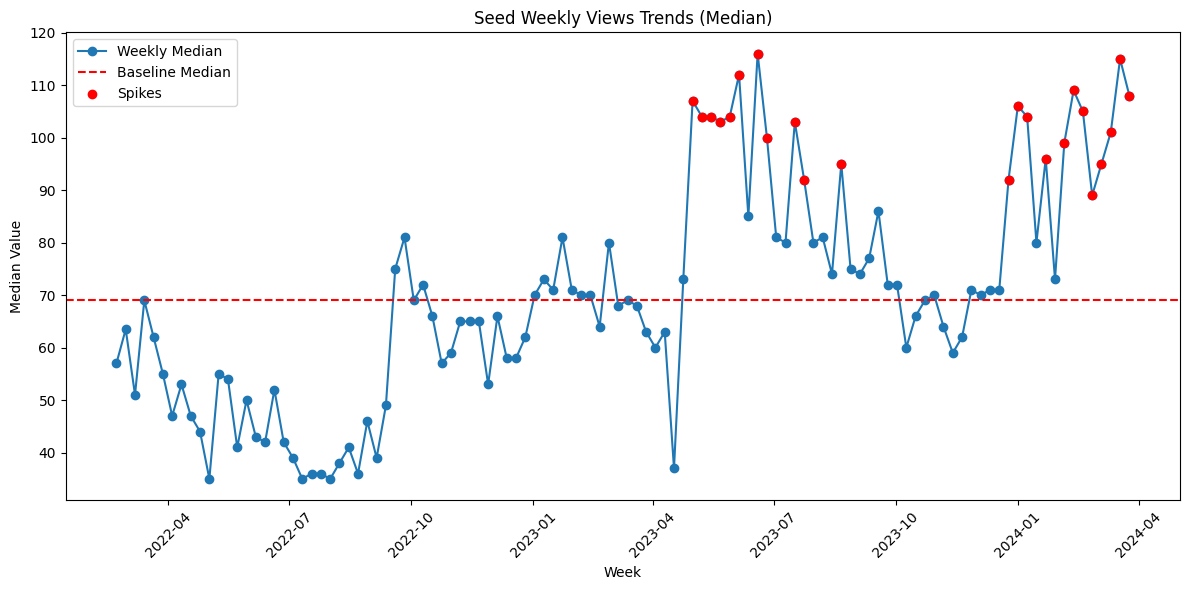

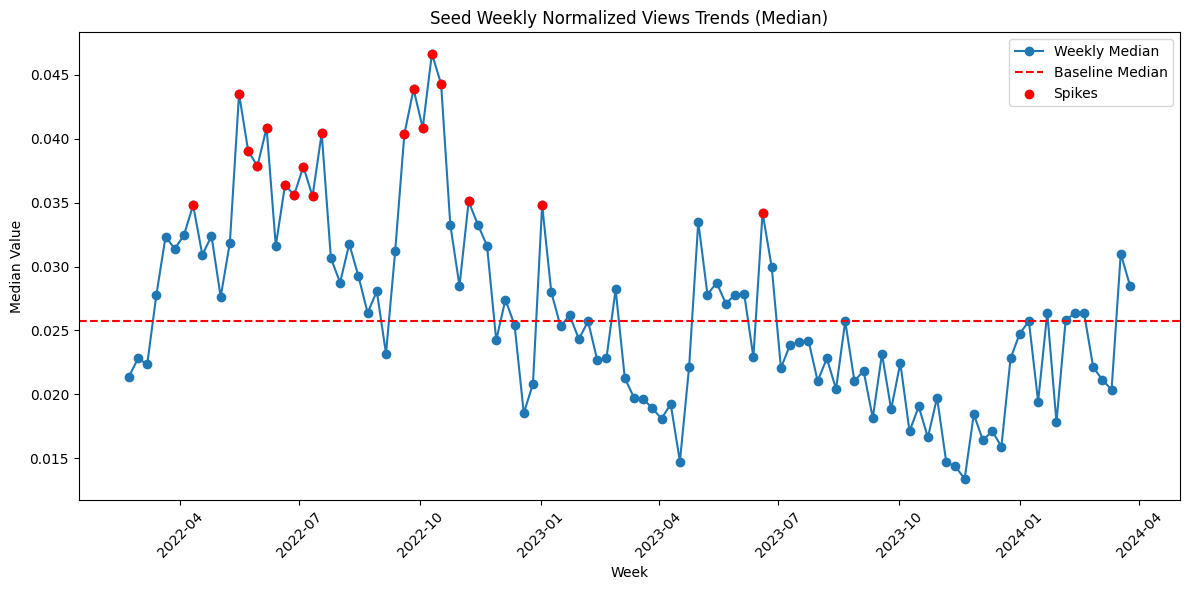

In [32]:
def find_weekly_spikes_median(df, value_column, date_column='date', threshold_factor=1.5):
    # Ensure the date column is in datetime format
    df[date_column] = pd.to_datetime(df[date_column])
    
    # Create a new column for the week (start of the week)
    df['week'] = df[date_column].dt.to_period('W').apply(lambda r: r.start_time)
    
    # Aggregate weekly data
    weekly_aggregated = df.groupby('week')[value_column].median().reset_index()
    weekly_aggregated.rename(columns={value_column: 'weekly_median'}, inplace=True)
    
    # Calculate baseline and threshold using MAD
    baseline_median = weekly_aggregated['weekly_median'].median()
    mad = (weekly_aggregated['weekly_median'] - baseline_median).abs().median()
    threshold = baseline_median + threshold_factor * mad
    
    # Identify weeks with spikes
    weekly_aggregated['is_spike'] = weekly_aggregated['weekly_median'] > threshold
    
    # Filter for spike weeks
    spikes = weekly_aggregated[weekly_aggregated['is_spike']]
    
    print(f"Baseline Median: {baseline_median:.2f}, MAD: {mad:.2f}, Threshold: {threshold:.2f}")
    print(f"Number of spike weeks: {len(spikes)}")
    return spikes, weekly_aggregated

# Apply this to bridge_df and seed_df for 'number_forwards' and 'normalized_number_forwards(Only_Subscriber)'
print("Bridge DataFrame - Weekly Spikes in forwards (Median):")
bridge_weekly_spikes_forwards_median, bridge_weekly_data_forwards_median = find_weekly_spikes_median(bridge_df, 'number_forwards')

print("Bridge DataFrame - Weekly Spikes in Normalized Views (Median):")
bridge_weekly_spikes_norm_median, bridge_weekly_data_norm_median = find_weekly_spikes_median(bridge_df, 'normalized_number_forwards(Only_Subscriber)')

print("Seed DataFrame - Weekly Spikes in Views (Median):")
seed_weekly_spikes_forwards_median, seed_weekly_data_forwards_median = find_weekly_spikes_median(seed_df, 'number_forwards')

print("Seed DataFrame - Weekly Spikes in Normalized Views (Median):")
seed_weekly_spikes_norm_median, seed_weekly_data_norm_median = find_weekly_spikes_median(seed_df, 'normalized_number_forwards(Only_Subscriber)')

# Visualization (optional)
import matplotlib.pyplot as plt
def plot_weekly_trends_median(weekly_data, value_column='weekly_median', spike_column='is_spike', title='Weekly Trends (Median)'):
    plt.figure(figsize=(12, 6))
    plt.plot(weekly_data['week'], weekly_data[value_column], label='Weekly Median', marker='o')
    plt.axhline(y=weekly_data[value_column].median(), color='r', linestyle='--', label='Baseline Median')
    spike_weeks = weekly_data[weekly_data[spike_column]]
    plt.scatter(spike_weeks['week'], spike_weeks[value_column], color='red', label='Spikes', zorder=5)
    plt.xlabel('Week')
    plt.ylabel('Median Value')
    plt.title(title)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot results for bridge_df views (median)
plot_weekly_trends_median(bridge_weekly_data_forwards_median, title='Bridge Weekly Views Trends (Median)')

# Plot results for bridge_df normalized views (median)
plot_weekly_trends_median(bridge_weekly_data_norm_median, title='Bridge Weekly Normalized Views Trends (Median)')

# Plot results for seed_df views (median)
plot_weekly_trends_median(seed_weekly_data_forwards_median, title='Seed Weekly Views Trends (Median)')

# Plot results for seed_df normalized views (median)
plot_weekly_trends_median(seed_weekly_data_norm_median, title='Seed Weekly Normalized Views Trends (Median)')

In [33]:
# Get the exact dates of the weekly peaks (using median-based spikes)
def get_peak_weeks_median(spike_data, weekly_data, date_column='week'):
    peak_weeks = weekly_data[weekly_data['week'].isin(spike_data['week'])]
    peak_weeks_dates = peak_weeks[date_column]
    return peak_weeks_dates

# For Bridge DataFrame (forwards - Median)
bridge_peak_weeks_forwards_median = get_peak_weeks_median(bridge_weekly_spikes_forwards_median, bridge_weekly_data_forwards_median)
print("Bridge Weekly Spikes (Exact Dates) - forwards (Median):")
print(bridge_peak_weeks_forwards_median)

# For Bridge DataFrame (Normalized forwards - Median)
bridge_peak_weeks_norm_median = get_peak_weeks_median(bridge_weekly_spikes_norm_median, bridge_weekly_data_norm_median)
print("Bridge Weekly Spikes (Exact Dates) - Normalized forwards (Median):")
print(bridge_peak_weeks_norm_median)

# For Seed DataFrame (forwards - Median)
seed_peak_weeks_forwards_median = get_peak_weeks_median(seed_weekly_spikes_forwards_median, seed_weekly_data_forwards_median)
print("Seed Weekly Spikes (Exact Dates) - forwards (Median):")
print(seed_peak_weeks_forwards_median)

# For Seed DataFrame (Normalized forwards - Median)
seed_peak_weeks_norm_median = get_peak_weeks_median(seed_weekly_spikes_norm_median, seed_weekly_data_norm_median)
print("Seed Weekly Spikes (Exact Dates) - Normalized forwards (Median):")
print(seed_peak_weeks_norm_median)

Bridge Weekly Spikes (Exact Dates) - forwards (Median):
31   2022-09-26
32   2022-10-03
33   2022-10-10
50   2023-02-06
62   2023-05-01
63   2023-05-08
68   2023-06-12
69   2023-06-19
70   2023-06-26
71   2023-07-03
72   2023-07-10
73   2023-07-17
74   2023-07-24
75   2023-07-31
76   2023-08-07
77   2023-08-14
78   2023-08-21
79   2023-08-28
80   2023-09-04
81   2023-09-11
82   2023-09-18
84   2023-10-02
85   2023-10-09
86   2023-10-16
87   2023-10-23
89   2023-11-06
Name: week, dtype: datetime64[ns]
Bridge Weekly Spikes (Exact Dates) - Normalized forwards (Median):
0     2022-02-21
1     2022-02-28
2     2022-03-07
5     2022-03-28
6     2022-04-04
7     2022-04-11
8     2022-04-18
9     2022-04-25
10    2022-05-02
11    2022-05-09
12    2022-05-16
30    2022-09-19
33    2022-10-10
46    2023-01-09
50    2023-02-06
62    2023-05-01
64    2023-05-15
67    2023-06-05
69    2023-06-19
70    2023-06-26
71    2023-07-03
108   2024-03-18
109   2024-03-25
Name: week, dtype: datetime64[ns]
Se

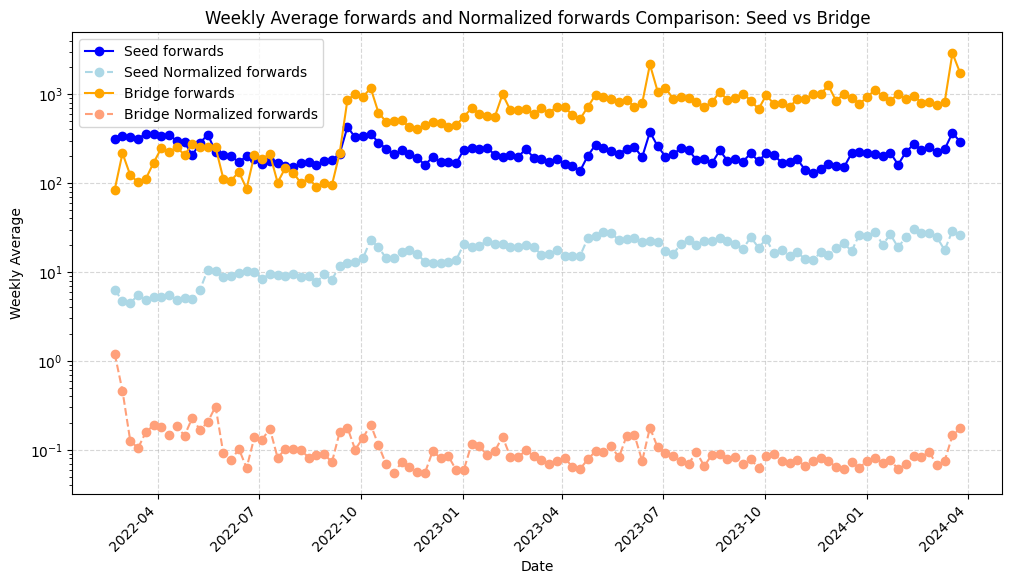

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'date' columns are datetime objects
seed_df['date'] = pd.to_datetime(seed_df['date'])
bridge_df['date'] = pd.to_datetime(bridge_df['date'])

# Group by week and calculate weekly averages for number_forwards and normalized_number_forwards
seed_weekly_avg = seed_df.groupby(seed_df['date'].dt.to_period('W'))[['number_forwards', 'normalized_number_forwards(Only_Subscriber)']].mean().reset_index()
bridge_weekly_avg = bridge_df.groupby(bridge_df['date'].dt.to_period('W'))[['number_forwards', 'normalized_number_forwards(Only_Subscriber)']].mean().reset_index()

# Convert the period back to a timestamp for easier plotting
seed_weekly_avg['date'] = seed_weekly_avg['date'].dt.to_timestamp()
bridge_weekly_avg['date'] = bridge_weekly_avg['date'].dt.to_timestamp()

# Create the plot
plt.figure(figsize=(12, 6))

# Plot for Seed dataset
plt.plot(
    seed_weekly_avg['date'], 
    seed_weekly_avg['number_forwards'], 
    label='Seed forwards', 
    marker='o', 
    linestyle='-', 
    color='blue'
)
plt.plot(
    seed_weekly_avg['date'], 
    seed_weekly_avg['normalized_number_forwards(Only_Subscriber)'], 
    label='Seed Normalized forwards', 
    marker='o', 
    linestyle='--', 
    color='lightblue'
)

# Plot for Bridge dataset
plt.plot(
    bridge_weekly_avg['date'], 
    bridge_weekly_avg['number_forwards'], 
    label='Bridge forwards', 
    marker='o', 
    linestyle='-', 
    color='orange'
)
plt.plot(
    bridge_weekly_avg['date'], 
    bridge_weekly_avg['normalized_number_forwards(Only_Subscriber)'], 
    label='Bridge Normalized forwards', 
    marker='o', 
    linestyle='--', 
    color='lightsalmon'
)

# Labels, title, and legend
plt.xlabel('Date')
plt.yscale('log')
plt.ylabel('Weekly Average')
plt.title('Weekly Average forwards and Normalized forwards Comparison: Seed vs Bridge')
plt.legend()

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Show plot
plt.grid(alpha=0.5, linestyle='--')
plt.show()
